In [1]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
# import openseespy.postprocessing.Get_Rendering as opsplt

In [2]:
import sys
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")
import solver_function as SF
import importlib
importlib.reload(SF)
from solver_function import *

In [3]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\opensees_test\Lib\site-packages\openseespywin\opensees.pyi!

In [4]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='drucker_pager.tcl',
                output_file='drucker_pager.tcl.py',
                prefix="ops")

In [5]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (88745484766)>


In [6]:
rhoS = 1.8  # Saturated soil mass density
Gr = 1e5  # Reference Shear modulus
Kr = 1.7e5  # Reference Bulk modulus
phi = 35.5  # Peak friction angle
gamax = 0.085  # Peak shear strain
pr = 100  # Reference mean effective pressure
D = 0.5  # Pressure dependence coefficient
PT = 31  # Phase Trasformation angle
c1 = 0.125  # Const for contraction
c3 = 1  # Const for contraction
d1 = 0.25  # Const for dilation
d3 = 5.7  # Const for dilation
NYS = 30  # Number of Yield Surfaces
c2 = 0.5  # Const for contraction
d2 = 3.9  # Const for dilation
l1 = 1.95  # Damage Parameter
l2 = 0  # Damage Parameter
Bf = 2.2e6  # Fluid bulk modulus
e = 0.9  # Soil void ratio
n = e / (1 + e)  # Soil porosity
Bc = Bf / n  # Combined bulk modulus
perm = 1e-16  # Perm. −undrained response−
#
# Rayleigh damping parameters
#
# Define Rayleigh Damping
period = 1.0
rayleigh_damping1 = 0.001
rayleigh_damping2 = 0.001
rayleigh_w1 = 2 * math.pi / period
rayleigh_w2 = 2 * math.pi / (period / 2.0)
Kinitproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (-1.0 * rayleigh_damping1 / rayleigh_w1 + 1.0 * rayleigh_damping2 / rayleigh_w2)
Mproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (rayleigh_damping1 * rayleigh_w1 - rayleigh_damping2 * rayleigh_w2)

In [7]:
ops.wipe()
ops.model('BasicBuilder', '-ndm', 3, '-ndf', 3)
ops.node(1, 1.0, 0.0, 0.0)
ops.node(2, 1.0, 1.0, 0.0)
ops.node(3, 0.0, 1.0, 0.0)
ops.node(4, 0.0, 0.0, 0.0)
ops.node(5, 1.0, 0.0, 1.0)
ops.node(6, 1.0, 1.0, 1.0)
ops.node(7, 0.0, 1.0, 1.0)
ops.node(8, 0.0, 0.0, 1.0)
ops.fix(1, 0, 1, 1)
ops.fix(2, 0, 0, 1)
ops.fix(3, 1, 0, 1)
ops.fix(4, 1, 1, 1)
ops.fix(5, 0, 1, 0)
ops.fix(6, 0, 0, 0)
ops.fix(7, 1, 0, 0)
ops.fix(8, 1, 1, 0)
ops.nDMaterial('DruckerPrager', 2, 27777.78, 9259.26, 5.0, 0.398, 0.398, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.7) # 9259.26
# ops.nDMaterial('PressureDependMultiYield02', 1, 3, rhoS, Gr, Kr, phi,
#                gamax, pr, D, PT, c1, c3, d1, d3, NYS, c2, d2, l1, l2, e)
ops.element('stdBrick', 1, 1, 2, 3, 4, 5, 6, 7, 8, 2, 0.0, 0.0, 0.0)
print('model Built...')

model Built...


DruckerPrager nDmaterial - Written: K.Petek, P.Mackenzie-Helnwein, P.Arduino, U.Washington


In [8]:
ops.recorder('Node', '-file', '3ddisplacements1.out', '-time', '-dT', 0.1, '-nodeRange', 1, 8, '-dof', 1, 2, 3, 'disp')
ops.recorder('Element', '-ele', 1, '-time', '-file', '3dstress1.out', '-dT', 0.1, 'material', 2, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', '3dstrain1.out', '-dT', 0.1, 'material', 2, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', '3dstate1.out', '-dT', 0.1, 'material', 2, 'state')

3

In [9]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [10]:
ops.timeSeries('Path', 1, '-time', 0, 10,100, '-values', 0, 1, 1, '-factor', 1)
ops.pattern('Plain', 1, 1)
ops.load(1, -2.5, 0.0, 0.0)
ops.load(2, -2.5, -2.5, 0.0)
ops.load(3, 0.0, -2.5, 0.0)
ops.load(5, -2.5, 0.0, 0.0)
ops.load(6, -2.5, -2.5, 0.0)
ops.load(7, 0.0, -2.5, 0.0)

In [11]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [12]:
ops.timeSeries('Path', 2, '-time', 0, 10,100, '-values', 0, 1, 5, '-factor', 1)
ops.pattern('Plain', 2, 2)
ops.load(5, 0.0, 0.0, -2.5)
ops.load(6, 0.0, 0.0, -2.5)
ops.load(7, 0.0, 0.0, -2.5)
ops.load(8, 0.0, 0.0, -2.5)

In [13]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [14]:
ops.integrator('LoadControl', 0.1)
ops.numberer('RCM',)
ops.system('SparseGeneral',)
ops.constraints('Transformation',)
ops.test('NormDispIncr', 1e-05, 10, 1)
ops.algorithm('Newton',)
ops.analysis('Static',)
print('starting the hydrostatic analysis...')

starting the hydrostatic analysis...


In [15]:
ODB = opst.post.CreateODB(
    odb_tag=1,
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
for _ in range(1000):
    ops.analyze(1,)
    ODB.fetch_response_step()
ODB.save_response(zlib=True)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.09714e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.20185e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.96262e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 3.10317e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 6.3596e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 7.85046e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 8.32667e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 8.32667e-17)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Norm R: 1.88247e-16)

CTestNormDispIncr::test() - iteration: 1 current Norm: 4.15692e-06 (max: 1e-05, Nor

OPSTOOL ::  All responses data with _odb_tag = 1 saved in .opstool.output/RespStepData-1.nc!

In [16]:
node_resp = opst.post.get_nodal_responses(odb_tag=1)
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-1.nc ...

<xarray.Dataset> Size: 1MB
Dimensions:             (time: 1001, nodeTags: 8, DOFs: 6)
Coordinates:
  * time                (time) float64 8kB 0.0 0.1 0.2 0.3 ... 96.2 96.2 96.2
  * nodeTags            (nodeTags) int64 64B 1 2 3 4 5 6 7 8
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    vel                 (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    accel               (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    reaction            (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 192kB 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 32kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Dis

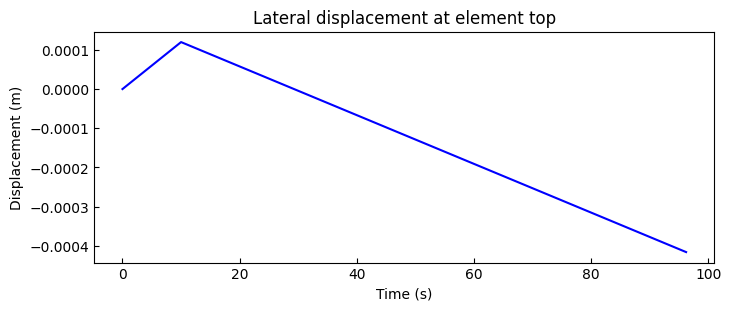

In [17]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [18]:
ele_resp = opst.post.get_element_responses(odb_tag=1, ele_type="Brick")

OPSTOOL ::  Loading Brick response data from .opstool.output/RespStepData-1.nc ...

In [19]:
print("Data Variables in Element Responses:", ele_resp.data_vars)

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 192kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 192kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 192kB 0.0 ......
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 192kB 0.0 ......
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 192kB 0.0 ......
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 192kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 224kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 224kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 224kB 0.0 ... 1...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 224kB 0.0 ... 0...


In [20]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1) # tr(σ)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1) # s+q kin, where s is the deviatoric stress tensor and q kin is the back-stress tensor
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1) # tr(εp)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1) 
#eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)
print(sigma22)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 8)> Size: 32kB
array([[  0.      ,   0.      ,   0.      , ...,   0.      ,   0.      ,
          0.      ],
       [ -0.1     ,  -0.1     ,  -0.1     , ...,  -0.1     ,  -0.1     ,
         -0.1     ],
       [ -0.2     ,  -0.2     ,  -0.2     , ...,  -0.2     ,  -0.2     ,
         -0.2     ],
       ...,
       [-10.007418, -10.007418, -10.007418, ..., -10.007418, -10.007418,
        -10.007418],
       [-10.007418, -10.007418, -10.007418, ..., -10.007418, -10.007418,
        -10.007418],
       [-10.007418, -10.007418, -10.007418, ..., -10.007418, -10.007418,
        -10.007418]], shape=(1001, 8), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.1 0.2 0.3 0.4 ... 96.2 96.2 96.2 96.2
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 64B 1 2 3 4 5 6 7 8
    stressDOFs   <U7 28B 'sigma22'


In [21]:
eps12_ele1_1 = sigma11.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)


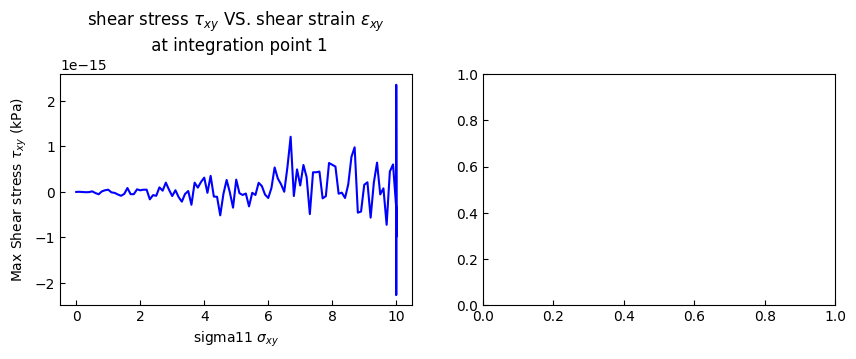

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(-eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"sigma11 $\sigma_{xy}$")
axs[0].set_ylabel(r"Max Shear stress $\tau_{xy}$ (kPa)")
plt.show()

In [23]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 8)> Size: 32kB
array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 2.3513585e-18, -4.0023121e-19, -1.5008670e-19, ...,
         4.8027744e-18, -3.4019656e-18,  7.2041625e-18],
       [-2.1012139e-18, -8.0046242e-19, -3.0017340e-19, ...,
         1.6009248e-18,  4.4025435e-18,  4.8027744e-18],
       ...,
       [-1.8058086e+01, -1.8058086e+01,  1.8058086e+01, ...,
        -1.8058086e+01,  1.8058086e+01, -1.8058086e+01],
       [-1.8058086e+01, -1.8058086e+01,  1.8058086e+01, ...,
        -1.8058086e+01,  1.8058086e+01, -1.8058086e+01],
       [-1.8058086e+01, -1.8058086e+01,  1.8058086e+01, ...,
        -1.8058086e+01,  1.8058086e+01, -1.8058086e+01]],
      shape=(1001, 8), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.1 0.2 0.3 0.4 ... 96.2 96.2 96.2 96.2
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 64B 1 2 3 4 5

In [24]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

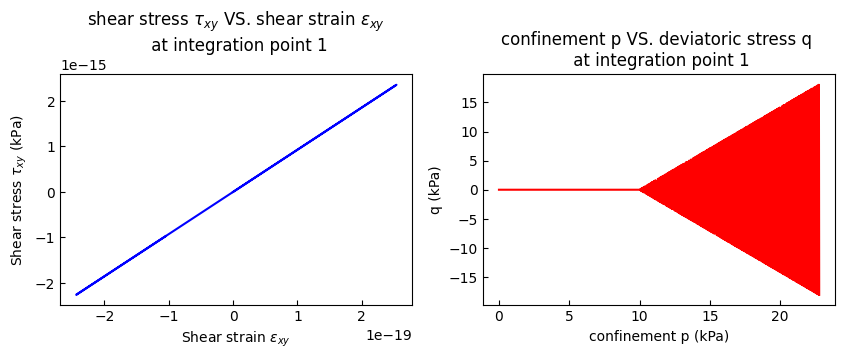

In [25]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [26]:
import matplotlib.pyplot as plt

import opstool as opst
import opstool.vis.pyvista as opsvis

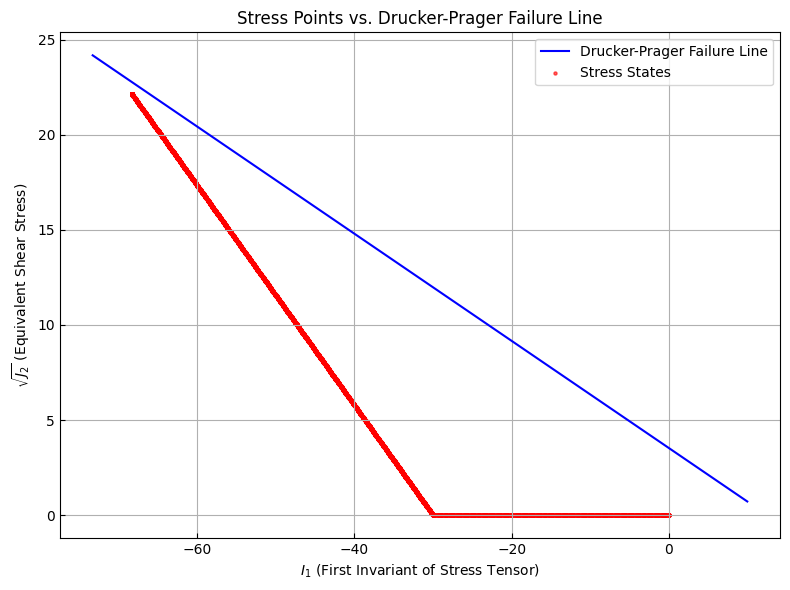

In [27]:
# drucker_prager_with_xarray.py

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Extract arrays from xarray (shape: [time, GaussPoints])
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1).values  # shape: (1001, 8)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1).values
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1).values

# Step 2: Compute I1 = σ11 + σ22 + σ33
I1_vals = sigma11 + sigma22 + sigma33  # First invariant of the stress tensor

# Step 3: Compute deviatoric stress s = σ - (1/3) I1
mean_stress = I1_vals / 3
s11 = sigma11 - mean_stress
s22 = sigma22 - mean_stress
s33 = sigma33 - mean_stress

# Step 4: Compute sqrt(J2) = sqrt(0.5 * (s11² + s22² + s33²))
J2_vals = 0.5 * (s11**2 + s22**2 + s33**2)
sqrt_J2_vals = np.sqrt(J2_vals)

# Step 5: Flatten for scatter plotting
I1_flat = I1_vals.flatten()
sqrt_J2_flat = sqrt_J2_vals.flatten()

# Step 6: Drucker-Prager failure line
rho = 0.398
sigma_Y = 5
I1_line = np.linspace(np.min(I1_flat)-5, np.max(I1_flat)+10, 500)
dp_line = - (1 / np.sqrt(2)) * rho * I1_line + (1 / np.sqrt(2)) * sigma_Y

# Step 7: Plot
plt.figure(figsize=(8, 6))
plt.plot(I1_line, dp_line, label='Drucker-Prager Failure Line', color='blue')
plt.scatter(I1_flat, sqrt_J2_flat, s=5, color='red', alpha=0.6, label='Stress States')

plt.xlabel(r'$I_1$ (First Invariant of Stress Tensor)')
plt.ylabel(r'$\sqrt{J_2}$ (Equivalent Shear Stress)')
plt.title('Stress Points vs. Drucker-Prager Failure Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
